In [ ]:
!pip install tensorflow

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

print(os.listdir('/content/drive/MyDrive/dog - cat'))

['cats', 'dogs']


In [10]:
def read_and_decode(filename, resize_dims):
    # 1. Read the raw file
    img_bytes = tf.io.read_file(filename)
    # 2. Decode image data
    img = tf.image.decode_jpeg(img_bytes, channels=IMG_CHANNELS)
    # 3. Convert pixel values to floats in [0, 1]
    img = tf.image.convert_image_dtype(img, tf.float32)
    # 4. Resize the image to match desired dimensions
    img = tf.image.resize(img, resize_dims)
    return img

In [11]:
def parse_csvline(csv_line):
    # record_defaults specify the data types for each column
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)

    # Load the image
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

    # Convert label string to integer based on the CLASS_NAMES index
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label

In [12]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = ["dogs", "cats"]

In [13]:
import tensorflow as tf
import pathlib

# Path to your uploaded dataset
data_dir = pathlib.Path(r"/content/drive/MyDrive/dog - cat")
# Count JPG images
image_count = len(list(data_dir.glob('*/*.jpg')))

print("Images found:", image_count)
print("data_dir:", data_dir)

Images found: 76
data_dir: /content/drive/MyDrive/dog - cat


In [18]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/dog - cat",
    image_size=(224, 224),
    batch_size=32
)

Found 76 files belonging to 2 classes.


In [19]:
for image_batch, label_batch in train_dataset.take(0):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

In [20]:
# Build train_set.csv and eval_set.csv from local image paths
CLASS_NAMES_PY = CLASS_NAMES # Using the already defined CLASS_NAMES with plural names
import random
import math

TRAIN_CSV = '/tmp/train_set.csv'
EVAL_CSV  = '/tmp/eval_set.csv'

train_rows, eval_rows = [], []

for cls in CLASS_NAMES_PY:
    cls_dir = data_dir / cls
    images  = sorted(str(p) for p in cls_dir.glob('*.jpg'))
    random.shuffle(images)
    split = math.ceil(len(images) * 0.8)
    train_rows += [(p, cls) for p in images[:split]]
    eval_rows  += [(p, cls) for p in images[split:]]

random.shuffle(train_rows)
random.shuffle(eval_rows)

with open(TRAIN_CSV, 'w') as f:
    for path, label in train_rows:
        f.write(f'{path},{label}\n')

with open(EVAL_CSV, 'w') as f:
    for path, label in eval_rows:
        f.write(f'{path},{label}\n')

print(f'Train samples : {len(train_rows)}')
print(f'Eval  samples : {len(eval_rows)}')

Train samples : 62
Eval  samples : 14


In [21]:
train_dataset = (
    tf.data.TextLineDataset(TRAIN_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.TextLineDataset(EVAL_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

print('Datasets ready.')

Datasets ready.


In [22]:
for image_batch, label_batch in train_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels: [0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0]


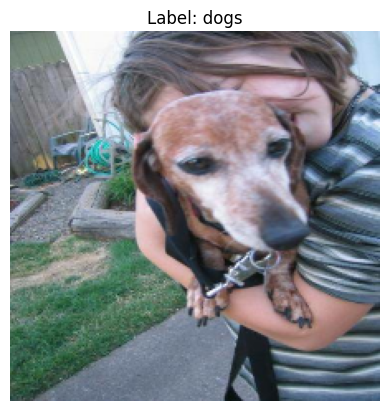

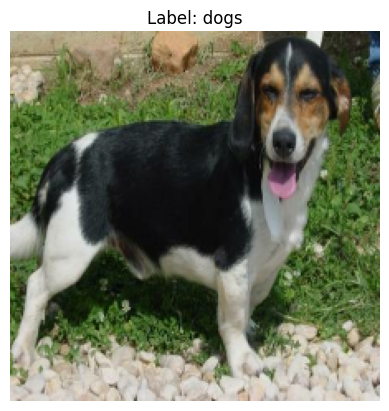

In [23]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

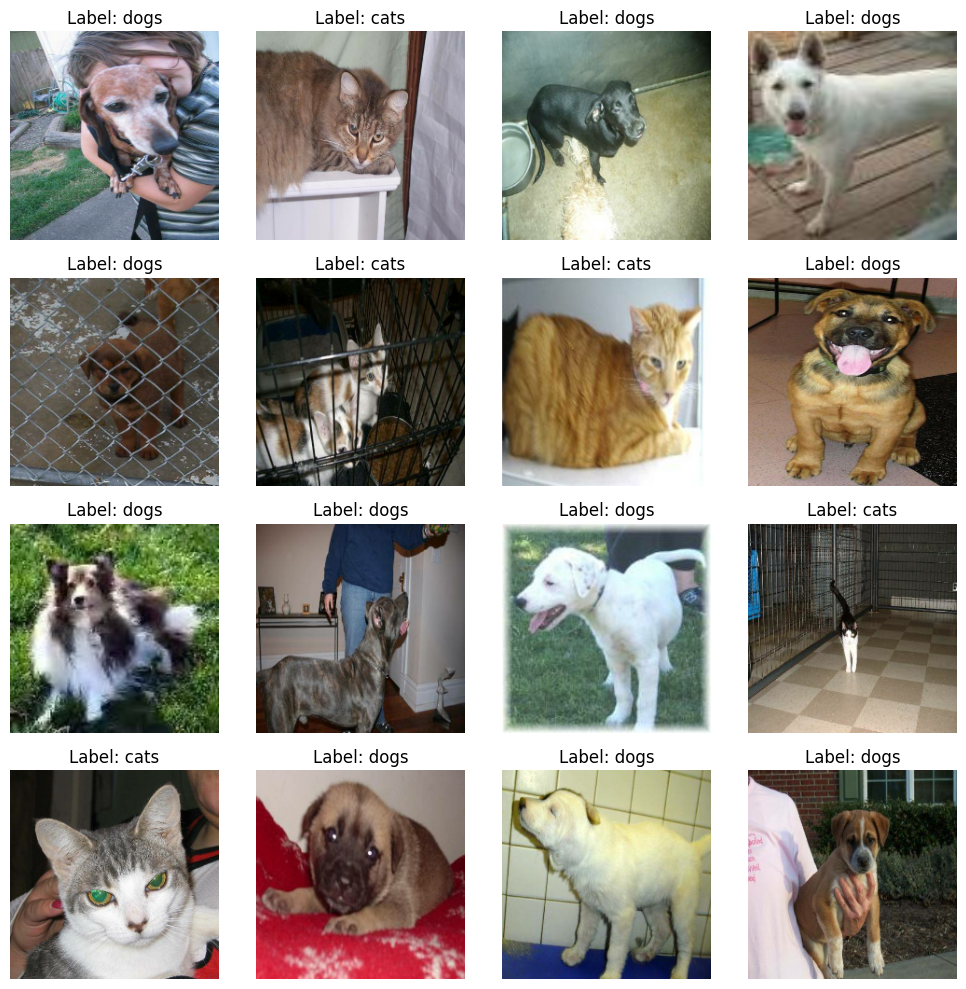

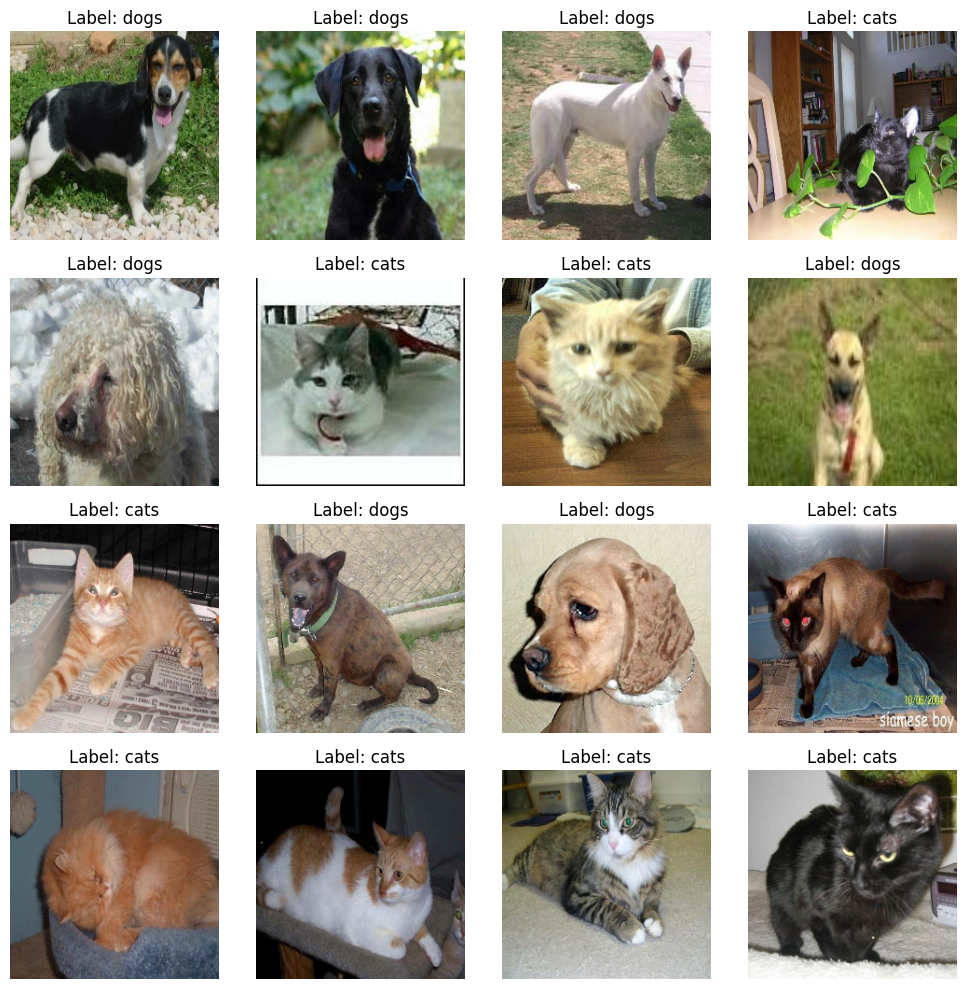

In [24]:
import matplotlib.pyplot as plt

# Take one batch from the dataset
for image_batch, label_batch in train_dataset.take(2):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))  # Create a 4x4 grid

    for i in range(16):  # Loop over the first 16 images
        ax = axes[i // 4, i % 4]  # Determine grid position
        ax.imshow(image_batch[i].numpy())  # Convert tensor to numpy array
        ax.set_title(f"Label: {CLASS_NAMES[label_batch[i]]}")
        ax.axis("off")  # Hide axes

    plt.tight_layout()
    plt.show()